In [1]:
import pandas as pd

In [2]:
# Load dataset (Assuming dataset is in CSV format)
df_powerball = pd.read_csv('Lottery_Powerball_Winning_Numbers__Beginning_2010_20240421.csv')

In [3]:
# assign winning numbers to order
col = "Winning Numbers"
df_powerball['Numbers_list'] = df_powerball[col].astype(str).str.replace(r'[^0-9\s]', ' ', regex=True).str.strip().str.split()
out_rows = []
for _, r in df_powerball.iterrows():
    date = r.get('Draw Date', r.get('DRAW_DATE', None))
    for pos, n in enumerate(r['Numbers_list'], start=1):
        out_rows.append({'Game':'Powerball', 'DrawDate':date, 'BallPosition':pos, 'Number':int(n)})
long_powerball = pd.DataFrame(out_rows)
long_powerball.to_csv("Powerball_for_tableau.csv", index=False)

In [4]:
# Load dataset (Assuming dataset is in CSV format)
df_mega = pd.read_csv('Lottery_Mega_Millions_Winning_Numbers__Beginning_2002_20240421.csv')

In [5]:
# assign winning numbers to order
col = "Winning Numbers"
df_mega['Numbers_list'] = df_mega[col].astype(str).str.replace(r'[^0-9\s]', ' ', regex=True).str.strip().str.split()
out_rows = []
for _, r in df_mega.iterrows():
    date = r.get('Draw Date', r.get('DRAW_DATE', None))
    for pos, n in enumerate(r['Numbers_list'], start=1):
        out_rows.append({'Game':'MegaMillions', 'DrawDate':date, 'BallPosition':pos, 'Number':int(n)})
long_mega = pd.DataFrame(out_rows)
long_mega.to_csv("Mega_for_tableau.csv", index=False)

In [6]:
# Load dataset (Assuming dataset is in CSV format)
df_pick10 = pd.read_csv('Lottery_Pick_10_Winning_Numbers__Beginning_1987_20240421.csv')

In [7]:
# assign winning numbers to order
col = "Winning Numbers"
df_pick10['Numbers_list'] = df_pick10[col].astype(str).str.replace(r'[^0-9\s]', ' ', regex=True).str.strip().str.split()
out_rows = []
for _, r in df_pick10.iterrows():
    date = r.get('Draw Date', r.get('DRAW_DATE', None))
    for pos, n in enumerate(r['Numbers_list'], start=1):
        out_rows.append({'Game':'Pick10', 'DrawDate':date, 'BallPosition':pos, 'Number':int(n)})
long_pick10 = pd.DataFrame(out_rows)
long_pick10.to_csv("Pick10_for_tableau.csv", index=False)

In [8]:
df_lottery = pd.concat([long_pick10, long_mega, long_powerball], ignore_index=True)

In [9]:
# save to CSV for Tableau
df_lottery.to_csv("lottery_combined.csv", index=False)

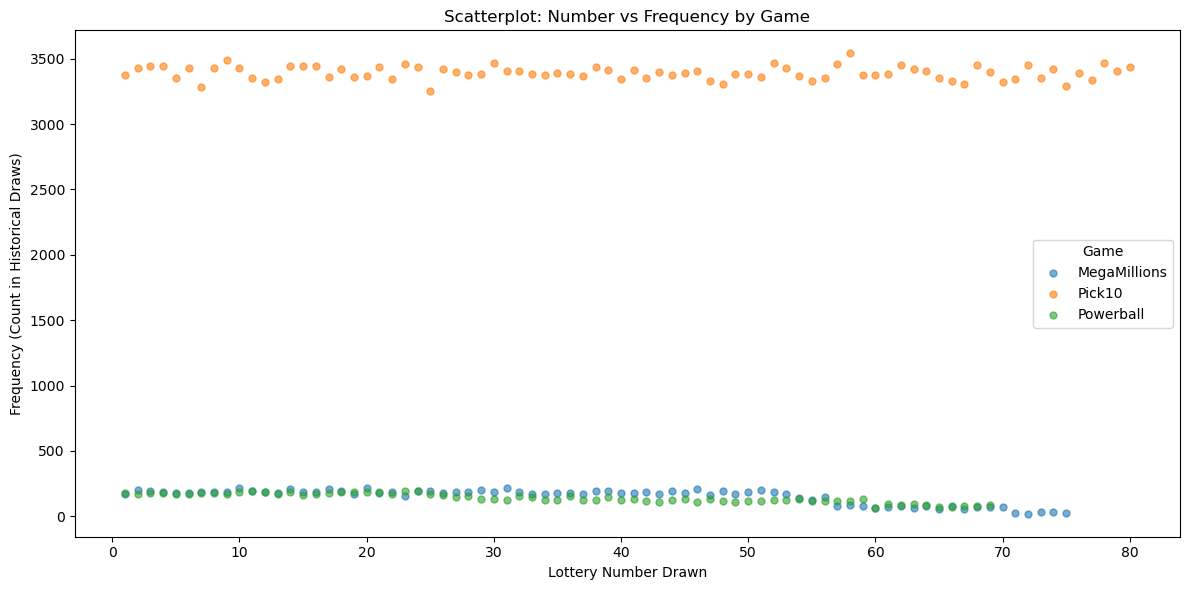

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Compute frequency table per game
# ---------------------------------------------------------

freq = (
    df_lottery
    .groupby(["Game", "Number"])
    .size()
    .reset_index(name="Frequency")
)

# ---------------------------------------------------------
# 2. Create the scatterplot with jitter
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

games = freq["Game"].unique()

for game in games:
    g = freq[freq["Game"] == game]
    
    # Create jitter for overlapping frequencies
    jitter = (np.random.rand(len(g)) - 0.5) * 0.5
    
    plt.scatter(
        g["Number"], 
        g["Frequency"] + jitter, 
        s=25, 
        label=game,
        alpha=0.6
    )

plt.xlabel("Lottery Number Drawn")
plt.ylabel("Frequency (Count in Historical Draws)")
plt.title("Scatterplot: Number vs Frequency by Game")
plt.legend(title="Game")
plt.tight_layout()

plt.show()